In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

In [24]:
load_dotenv()
BASE_PATH = os.getenv("BASE_PATH")
df = pd.read_csv(f'{BASE_PATH}/data/raw/Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 91.3 KB


In [26]:
df.drop(columns=['Order_ID'], inplace=True)

In [27]:
categorical_columns = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in categorical_columns: 
    df[col] = df[col].astype('category')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Distance_km             1000 non-null   float64 
 1   Weather                 970 non-null    category
 2   Traffic_Level           970 non-null    category
 3   Time_of_Day             970 non-null    category
 4   Vehicle_Type            1000 non-null   category
 5   Preparation_Time_min    1000 non-null   int64   
 6   Courier_Experience_yrs  970 non-null    float64 
 7   Delivery_Time_min       1000 non-null   int64   
dtypes: category(4), float64(2), int64(2)
memory usage: 35.5 KB


In [29]:
df.isna().sum()

Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [30]:
missing_columns = ['Weather', 'Traffic_Level','Time_of_Day']
for col in missing_columns: 
    df[col]= df[col].fillna(df[col].mode()[0])

In [31]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [32]:
df.loc[df["Delivery_Time_min"] < 0, "Delivery_Time_min"] = 0
(df["Delivery_Time_min"] < 0).sum()

np.int64(0)

In [33]:
# downcast Integer columns: 
int_columns = ['Courier_Experience_yrs', 'Preparation_Time_min', 'Delivery_Time_min']
for col in int_columns: 
    df[col] = df[col].astype('uint8') # range 0:255

In [34]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Distance_km             1000 non-null   float64 
 1   Weather                 1000 non-null   category
 2   Traffic_Level           1000 non-null   category
 3   Time_of_Day             1000 non-null   category
 4   Vehicle_Type            1000 non-null   category
 5   Preparation_Time_min    1000 non-null   uint8   
 6   Courier_Experience_yrs  1000 non-null   uint8   
 7   Delivery_Time_min       1000 non-null   uint8   
dtypes: category(4), float64(1), uint8(3)
memory usage: 15.4 KB


In [35]:
df = df.drop_duplicates()

In [36]:
df.shape

(1000, 8)

In [37]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print(f"{col}: {n_outliers} outliers")

Distance_km: 0 outliers
Preparation_Time_min: 0 outliers
Courier_Experience_yrs: 0 outliers
Delivery_Time_min: 6 outliers


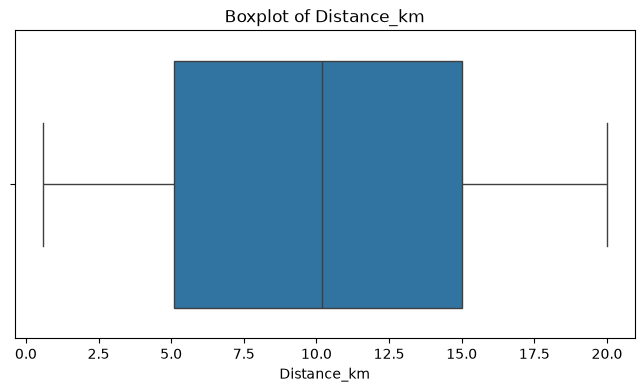

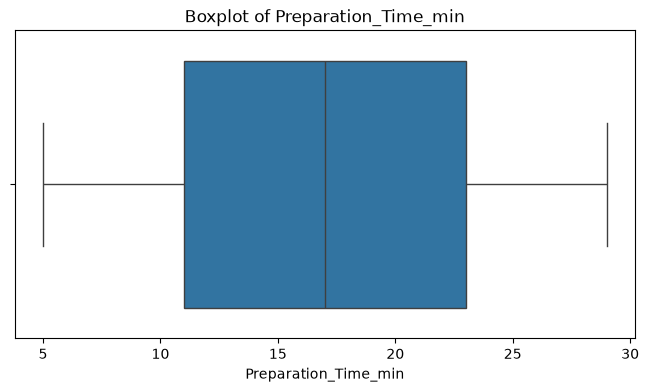

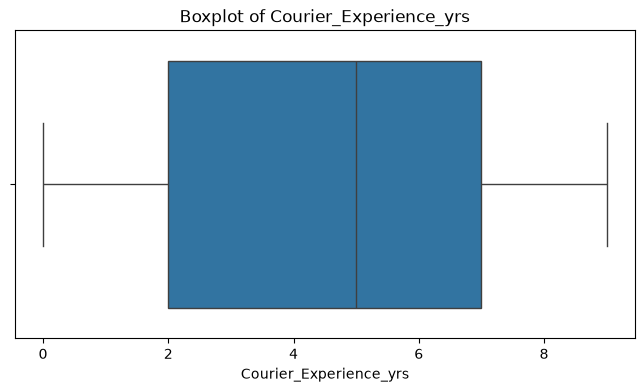

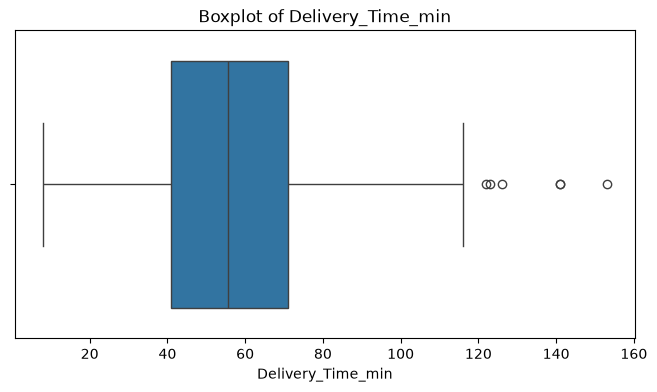

In [38]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [39]:
print(df['Delivery_Time_min'].min())
print(df['Delivery_Time_min'].max())

8
153


In [40]:
df['Delivery_Time_min'].nlargest(10)

379    153
127    141
452    141
784    126
29     123
924    122
140    116
550    116
495    115
926    114
Name: Delivery_Time_min, dtype: uint8

In [41]:
df["Distance_km"] = df["Distance_km"] * 1000
df.rename(columns={"Distance_km": "Distance_m"}, inplace=True)

In [42]:
df.to_parquet(
    f"{BASE_PATH}/data/processed/clean_delivery_time.parquet",
    index=False,
    engine="pyarrow"
)